In [3]:
import cv2
import os
import numpy as np
from sklearn.model_selection import train_test_split


base = '/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/'
f = ["normal",'benign','malignant']


images = []
y = []


for i in range(3):
    folder = base+f[i]
    for file in os.listdir(folder):
        if len(file)==len(file.replace('mask','')):
            path = os.path.join(folder, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (224, 224))
            images.append(img)
            y.append(i)

images = np.array(images)
y = np.array(y)
print("Total images:", images.shape)


# normalize
images = images / 255.0
images = images[..., None]   # (N,224,224,1)
X_train, X_test, y_train, y_test = train_test_split(
    images, y, test_size=0.2, random_state=11, stratify=y
)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Total images: (780, 224, 224)
Train classes: (array([0, 1, 2]), array([106, 350, 168]))
Test classes: (array([0, 1, 2]), array([27, 87, 42]))


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_7              │ (None, 224, 224, 8)    │            25 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 224, 224, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_8              │ (None, 112, 112, 8)    │           144 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_9              │ (None, 56, 56, 8)      │           144 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 56, 56, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_10             │ (None, 28, 28, 8)      │           144 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_11             │ (None, 14, 14, 8)      │           144 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_12             │ (None, 7, 7, 8)        │           144 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           21

 Total params: 964 (3.77 KB)

 Trainable params: 964 (3.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.4749 - loss: 1.0928 - val_accuracy: 0.5577 - val_loss: 1.0627
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5597 - loss: 1.0279 - val_accuracy: 0.5577 - val_loss: 0.9770
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5515 - loss: 0.9867 - val_accuracy: 0.5577 - val_loss: 0.9758
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5814 - loss: 0.9577 - val_accuracy: 0.5577 - val_loss: 0.9741
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5767 - loss: 0.9442 - val_accuracy: 0.5577 - val_loss: 0.9737
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5558 - loss: 0.9795 - val_accuracy: 0.5577 - val_loss: 0.9710
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5597 - loss: 0.9673 - val_accuracy: 0.5577 - val_loss: 0.9691
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5653 - loss: 0.9453 - val_accuracy: 0.

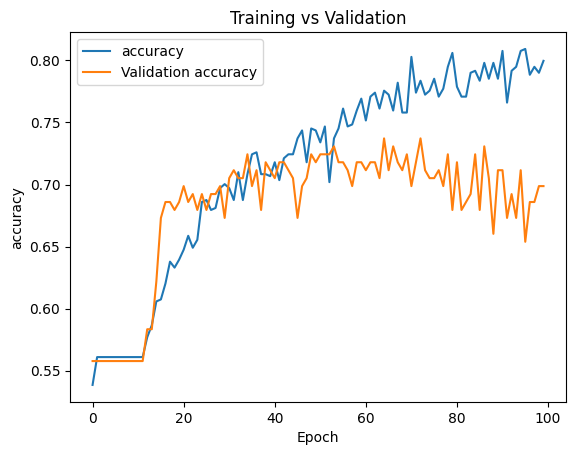


 Best Validation Accuracy: 0.7371794581413269


In [11]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

l2 = regularizers.l2(1e-4)

def conv_block(x, filters):
    x = layers.SeparableConv2D(
        filters,
        (3,3),
        padding='same',
    )(x)
    
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    
    return x


def cmodel():
    inputs = layers.Input(shape=(224,224,1))
    
    x = conv_block(inputs, 8)
    x = conv_block(x, 8)
    x = conv_block(x, 8)
    x = conv_block(x, 8)
    x = conv_block(x, 8)
    x = conv_block(x, 8)
    
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(3, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    return model

model = cmodel()
model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


checkpoint = ModelCheckpoint(
    "best_model.keras",      # file name
    monitor="val_accuracy",       # watch validation accuracy
    save_best_only=True,          # save only best model
    mode="max"
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint]
)

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.title('Training vs Validation')
plt.legend()
plt.show()

print("\n Best Validation Accuracy:", max(history.history['val_accuracy']))

In [ ]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model = tf.keras.models.load_model("/kaggle/working/best_model.keras")

yp = model.predict(X_train)
print('training data')
cm = confusion_matrix(y_train, np.argmax(yp,axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=f)
disp.plot(cmap='Blues')
plt.show()

yp = model.predict(X_test)
print('testing data')
cm = confusion_matrix(y_test, np.argmax(yp,axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=f)
disp.plot(cmap='Blues')
plt.show()

11/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


 predicted: benign  actual: benign


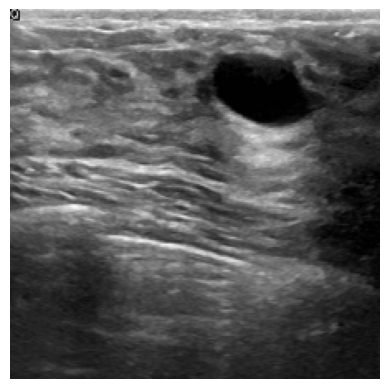


 predicted: benign  actual: malignant


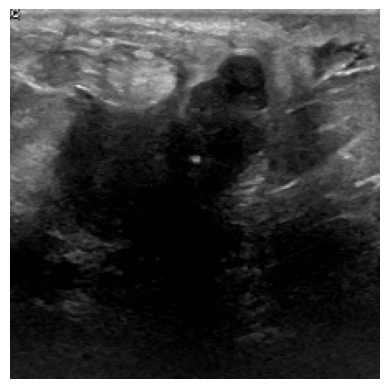


 predicted: benign  actual: malignant


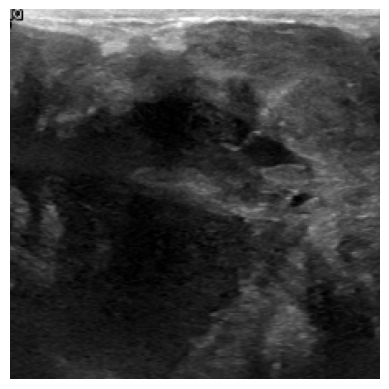


 predicted: benign  actual: malignant


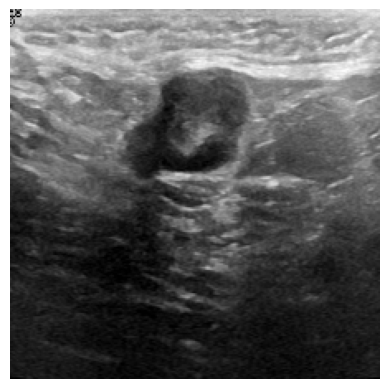


 predicted: malignant  actual: malignant


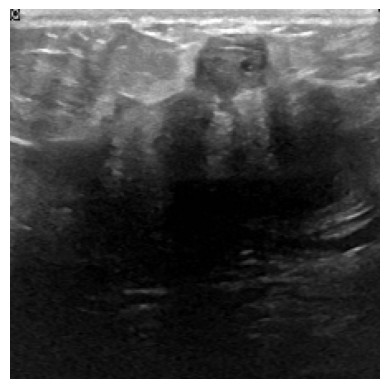


 predicted: benign  actual: benign


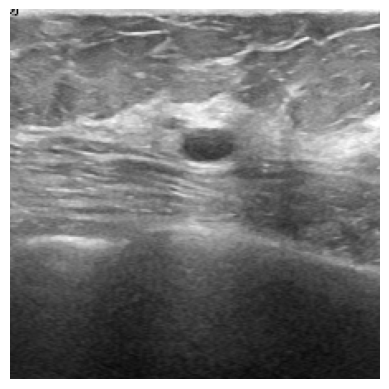


 predicted: benign  actual: malignant


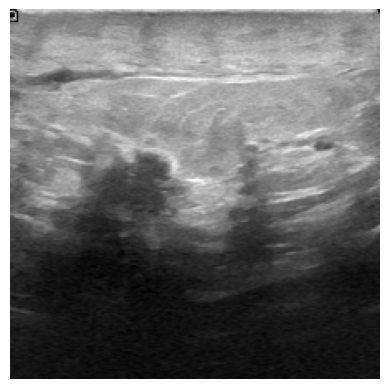


 predicted: benign  actual: benign


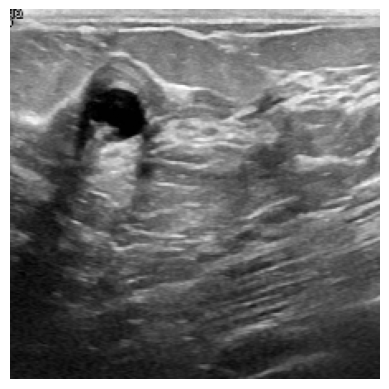


 predicted: benign  actual: malignant


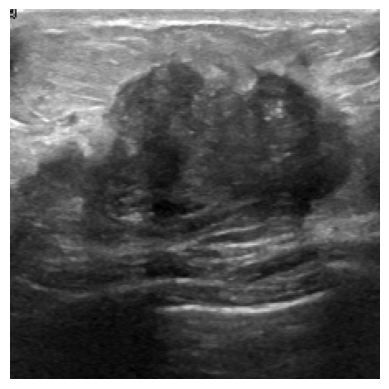


 predicted: benign  actual: malignant


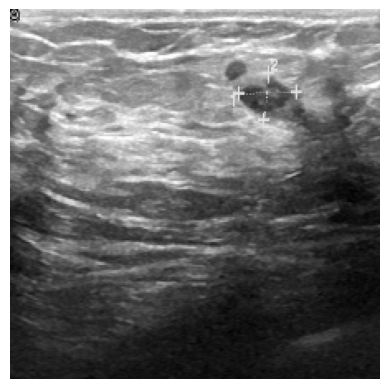

In [10]:
for i in range(10):
    print('\n predicted:',f[np.argmax(yp[i])],' actual:',f[y_test[i]])
    plt.imshow(X_test[i],cmap='gray')
    plt.axis('off')
    plt.show()